# 05 Lightweight Vision Transformer Model

Lightweight Vision Transformer experiment for handwritten Chinese character recognition.


In [ ]:
from google.colab import drive

# Mount Google Drive to access dataset files and save experiment results
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Libraries


In [ ]:
import json
import pickle
import time
import copy
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from tqdm import tqdm


## Load Metadata and Cross-Validation Folds


In [ ]:
METADATA_PATH = Path("/content/drive/MyDrive/Diploma/CASIA_246_metadata.json")
FOLDS_PATH = Path("/content/drive/MyDrive/Diploma/CASIA_246_5folds.pkl")

with open(METADATA_PATH, "r", encoding="utf-8") as file:
    metadata = json.load(file)

with open(FOLDS_PATH, "rb") as file:
    folds = pickle.load(file)

NUM_CLASSES = metadata["number_of_classes"]
IMAGE_SIZE = metadata.get("image_size", 64)
BATCH_SIZE = metadata.get("batch_size", 64)

class_to_idx = metadata["class_to_idx"]
idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

print("Number of classes:", NUM_CLASSES)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of folds:", len(folds))


Number of classes: 246
Image size: 64
Batch size: 64
Number of folds: 5


## Dataset Paths and Optional Extraction


In [ ]:
ZIP_PATH = Path("/content/drive/MyDrive/Diploma/CASIA_246.zip")

DATASET_DIR = Path("/content/CASIA_246")
TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

def fix_zip_filename(filename):
    # Fix filenames stored as UTF-8 but read as cp437
    try:
        return filename.encode("cp437").decode("utf-8")
    except (UnicodeEncodeError, UnicodeDecodeError):
        return filename

if not DATASET_DIR.exists():
    print("Dataset folder was not found. Extracting archive...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        for file_info in zip_ref.infolist():
            fixed_name = fix_zip_filename(file_info.filename)
            target_path = Path("/content") / fixed_name

            if file_info.is_dir():
                target_path.mkdir(parents=True, exist_ok=True)
            else:
                target_path.parent.mkdir(parents=True, exist_ok=True)

                with zip_ref.open(file_info) as source:
                    with open(target_path, "wb") as target:
                        target.write(source.read())

    print("Dataset extracted.")
else:
    print("Dataset already exists.")

assert TRAIN_DIR.exists(), f"Train folder not found: {TRAIN_DIR}"
assert TEST_DIR.exists(), f"Test folder not found: {TEST_DIR}"

print("Dataset directory:", DATASET_DIR)
print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

Dataset already exists.
Dataset directory: /content/CASIA_246
Train directory: /content/CASIA_246/train
Test directory: /content/CASIA_246/test


## Define Image Transformations


In [ ]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # Light augmentation keeps handwritten character shapes readable
    transforms.RandomRotation(degrees=5, fill=255),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.04, 0.04),
        scale=(0.95, 1.05),
        shear=3,
        fill=255
    ),

    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])


## Create PyTorch Datasets


In [ ]:
train_dataset_augmented = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transform
)

train_dataset_plain = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

assert len(train_dataset_augmented.classes) == NUM_CLASSES
assert train_dataset_augmented.class_to_idx == test_dataset.class_to_idx

class_to_idx = train_dataset_augmented.class_to_idx
idx_to_class = {
    index: class_name
    for class_name, index in class_to_idx.items()
}

print("Training images:", len(train_dataset_augmented))
print("Test images:", len(test_dataset))
print("Classes:", len(train_dataset_augmented.classes))

Training images: 147265
Test images: 35108
Classes: 246


## DataLoader Helper for Cross-Validation


In [ ]:
def create_fold_dataloaders(fold_index):
    train_indices, validation_indices = folds[fold_index]

    fold_train_dataset = Subset(train_dataset_augmented, train_indices)
    fold_validation_dataset = Subset(train_dataset_plain, validation_indices)

    fold_train_loader = DataLoader(
        fold_train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )

    fold_validation_loader = DataLoader(
        fold_validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    return fold_train_loader, fold_validation_loader, fold_train_dataset, fold_validation_dataset


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

for fold_index in range(len(folds)):
    fold_train_loader, fold_validation_loader, fold_train_dataset, fold_validation_dataset = create_fold_dataloaders(fold_index)

    print(
        f"Fold {fold_index + 1}: "
        f"train samples = {len(fold_train_dataset)}, "
        f"validation samples = {len(fold_validation_dataset)}, "
        f"train batches = {len(fold_train_loader)}, "
        f"validation batches = {len(fold_validation_loader)}"
    )

print("Test samples:", len(test_dataset))
print("Test batches:", len(test_loader))


Fold 1: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 2: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 3: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 4: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Fold 5: train samples = 117812, validation samples = 29453, train batches = 1841, validation batches = 461
Test samples: 35108
Test batches: 549


## Lightweight Vision Transformer Model


In [ ]:
PATCH_SIZE = 8
EMBED_DIM = 128
DEPTH = 4
NUM_HEADS = 4
MLP_DIM = 256
DROPOUT = 0.1


class LightweightViT(nn.Module):
    def __init__(
        self,
        image_size,
        patch_size,
        num_classes,
        embed_dim,
        depth,
        num_heads,
        mlp_dim,
        dropout
    ):
        super(LightweightViT, self).__init__()

        assert image_size % patch_size == 0, "Image size must be divisible by patch size."

        self.image_size = image_size
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.embed_dim = embed_dim

        # Patch embedding converts image patches into token embeddings
        self.patch_embed = nn.Conv2d(
            in_channels=1,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.position_embedding = nn.Parameter(torch.zeros(1, self.num_patches + 1, embed_dim))
        self.embedding_dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=depth
        )

        self.norm = nn.LayerNorm(embed_dim)

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, num_classes)
        )

        self._initialize_parameters()

    def _initialize_parameters(self):
        # Small initialization helps stabilize transformer training from scratch
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.position_embedding, std=0.02)

    def forward(self, x):
        x = self.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)

        batch_size = x.size(0)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)

        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.position_embedding
        x = self.embedding_dropout(x)

        x = self.transformer(x)

        cls_output = self.norm(x[:, 0])
        logits = self.classifier(cls_output)

        return logits


def create_lwvit_model(num_classes):
    return LightweightViT(
        image_size=IMAGE_SIZE,
        patch_size=PATCH_SIZE,
        num_classes=num_classes,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        mlp_dim=MLP_DIM,
        dropout=DROPOUT
    )


## Utility Functions


In [ ]:
def set_seed(seed=42):
    # Fix random seeds for reproducible experiments
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def count_parameters(model):
    # Count only trainable parameters
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def calculate_model_size_mb(model):
    # Estimate model size from parameters and buffers
    size_bytes = 0

    for parameter in model.parameters():
        size_bytes += parameter.numel() * parameter.element_size()

    for buffer in model.buffers():
        size_bytes += buffer.numel() * buffer.element_size()

    return size_bytes / (1024 ** 2)


def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_predictions = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)

        correct_predictions += (predictions == labels).sum().item()
        total_samples += batch_size

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        current_loss = running_loss / total_samples
        current_accuracy = correct_predictions / total_samples

        progress_bar.set_postfix({
            "loss": f"{current_loss:.4f}",
            "acc": f"{current_accuracy:.4f}"
        })

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_f1


def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_predictions = []
    all_labels = []

    progress_bar = tqdm(data_loader, desc="Validation", leave=False)

    with torch.no_grad():
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            batch_size = images.size(0)
            running_loss += loss.item() * batch_size

            predictions = outputs.argmax(dim=1)

            correct_predictions += (predictions == labels).sum().item()
            total_samples += batch_size

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            current_loss = running_loss / total_samples
            current_accuracy = correct_predictions / total_samples

            progress_bar.set_postfix({
                "loss": f"{current_loss:.4f}",
                "acc": f"{current_accuracy:.4f}"
            })

    epoch_loss = running_loss / len(data_loader.dataset)
    epoch_accuracy = accuracy_score(all_labels, all_predictions)
    epoch_f1 = f1_score(all_labels, all_predictions, average="macro", zero_division=0)

    return epoch_loss, epoch_accuracy, epoch_f1


def train_model(model, train_loader, validation_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_model_weights = copy.deepcopy(model.state_dict())
    best_validation_accuracy = 0.0
    best_validation_f1 = 0.0

    history = []
    total_start_time = time.time()

    for epoch in range(epochs):
        epoch_start_time = time.time()

        print(f"\nEpoch {epoch + 1}/{epochs}")

        train_loss, train_accuracy, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        validation_loss, validation_accuracy, validation_f1 = evaluate_model(
            model, validation_loader, criterion, device
        )

        scheduler.step(validation_accuracy)

        epoch_time = time.time() - epoch_start_time
        current_lr = optimizer.param_groups[0]["lr"]

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            best_validation_f1 = validation_f1
            best_model_weights = copy.deepcopy(model.state_dict())

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "validation_loss": validation_loss,
            "train_accuracy": train_accuracy,
            "validation_accuracy": validation_accuracy,
            "train_f1": train_f1,
            "validation_f1": validation_f1,
            "learning_rate": current_lr,
            "epoch_time": epoch_time
        })

        print(
            f"train_loss={train_loss:.4f} | "
            f"val_loss={validation_loss:.4f} | "
            f"train_acc={train_accuracy:.4f} | "
            f"val_acc={validation_accuracy:.4f} | "
            f"train_f1={train_f1:.4f} | "
            f"val_f1={validation_f1:.4f} | "
            f"lr={current_lr:.6f} | "
            f"time={epoch_time:.1f}s"
        )

    total_training_time = time.time() - total_start_time

    model.load_state_dict(best_model_weights)
    history_df = pd.DataFrame(history)

    return model, history_df, best_validation_accuracy, best_validation_f1, total_training_time


def get_predictions(model, data_loader, device):
    model.eval()

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Collecting predictions"):
            images = images.to(device)

            outputs = model(images)
            predictions = outputs.argmax(dim=1).cpu()

            all_labels.append(labels)
            all_predictions.append(predictions)

    all_labels = torch.cat(all_labels)
    all_predictions = torch.cat(all_predictions)

    return all_labels, all_predictions


## Model Summary


In [ ]:
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

sample_model = create_lwvit_model(NUM_CLASSES).to(device)

print(sample_model)

num_parameters = count_parameters(sample_model)
model_size_mb = calculate_model_size_mb(sample_model)

print("\nTrainable parameters:", num_parameters)
print("Estimated model size:", round(model_size_mb, 2), "MB")

sample_train_loader, _, _, _ = create_fold_dataloaders(0)

images, labels = next(iter(sample_train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = sample_model(images)

print("\nInput shape:", images.shape)
print("Output shape:", outputs.shape)


Device: cuda


/tmp/ipykernel_18623/3833086799.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


LightweightViT(
  (patch_embed): Conv2d(1, 128, kernel_size=(8, 8), stride=(8, 8))
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
 

## Train LW-ViT


In [11]:
EPOCHS = 10
LEARNING_RATE = 0.001

BASE_OUTPUT_DIR = Path("/content/drive/MyDrive/Diploma/diploma_hccr")

MODELS_DIR = BASE_OUTPUT_DIR / "models"
HISTORIES_DIR = BASE_OUTPUT_DIR / "histories"
RESULTS_DIR = BASE_OUTPUT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
HISTORIES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fold_summaries = []
all_histories = []

best_overall_accuracy = 0.0
best_overall_f1 = 0.0
best_overall_fold = None
best_overall_model_state = None

cross_validation_start_time = time.time()

for fold_index in range(len(folds)):
    print("\n" + "=" * 60)
    print(f"Fold {fold_index + 1}/{len(folds)}")
    print("=" * 60)

    set_seed(42 + fold_index)

    fold_train_loader, fold_validation_loader, fold_train_dataset, fold_validation_dataset = create_fold_dataloaders(fold_index)

    model = create_lwvit_model(NUM_CLASSES).to(device)

    model, fold_history_df, best_validation_accuracy, best_validation_f1, fold_training_time = train_model(
        model=model,
        train_loader=fold_train_loader,
        validation_loader=fold_validation_loader,
        epochs=EPOCHS,
        learning_rate=LEARNING_RATE,
        device=device
    )

    fold_history_df["fold"] = fold_index + 1
    all_histories.append(fold_history_df)

    fold_model_path = MODELS_DIR / f"lwvit_fold_{fold_index + 1}.pth"

    torch.save({
        "model_name": "LW-ViT",
        "fold": fold_index + 1,
        "model_state_dict": model.state_dict(),
        "num_classes": NUM_CLASSES,
        "image_size": IMAGE_SIZE,
        "class_to_idx": train_dataset_augmented.class_to_idx,
        "patch_size": PATCH_SIZE,
        "embed_dim": EMBED_DIM,
        "depth": DEPTH,
        "num_heads": NUM_HEADS,
        "mlp_dim": MLP_DIM,
        "dropout": DROPOUT,
        "best_validation_accuracy": best_validation_accuracy,
        "best_validation_f1": best_validation_f1
    }, fold_model_path)

    fold_summaries.append({
        "model_name": "LW-ViT",
        "fold": fold_index + 1,
        "best_validation_accuracy": best_validation_accuracy,
        "best_validation_f1": best_validation_f1,
        "training_time": fold_training_time,
        "average_epoch_time": fold_history_df["epoch_time"].mean(),
        "model_path": str(fold_model_path)
    })

    print(f"Fold {fold_index + 1} best validation accuracy: {best_validation_accuracy:.4f}")
    print(f"Fold {fold_index + 1} best validation macro F1-score: {best_validation_f1:.4f}")
    print(f"Fold {fold_index + 1} training time: {fold_training_time / 60:.2f} minutes")

    if best_validation_accuracy > best_overall_accuracy:
        best_overall_accuracy = best_validation_accuracy
        best_overall_f1 = best_validation_f1
        best_overall_fold = fold_index + 1
        best_overall_model_state = copy.deepcopy(model.state_dict())

total_training_time = time.time() - cross_validation_start_time

history_df = pd.concat(all_histories, ignore_index=True)
cv_summary_df = pd.DataFrame(fold_summaries)

print("\nCross-validation complete.")
print("Best fold:", best_overall_fold)
print("Best validation accuracy:", round(best_overall_accuracy, 4))
print("Best validation macro F1-score:", round(best_overall_f1, 4))
print("Total cross-validation time:", round(total_training_time, 2), "seconds")
print("Total cross-validation time:", round(total_training_time / 60, 2), "minutes")

print("\nMean validation accuracy:", round(cv_summary_df["best_validation_accuracy"].mean(), 4))
print("Mean validation macro F1-score:", round(cv_summary_df["best_validation_f1"].mean(), 4))
print("Validation accuracy std:", round(cv_summary_df["best_validation_accuracy"].std(), 4))
print("Validation F1-score std:", round(cv_summary_df["best_validation_f1"].std(), 4))


/tmp/ipykernel_18623/3833086799.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(



Fold 1/5

Epoch 1/10


train_loss=4.8507 | val_loss=3.8896 | train_acc=0.0368 | val_acc=0.1026 | train_f1=0.0308 | val_f1=0.0773 | lr=0.001000 | time=139.5s

Epoch 2/10


train_loss=3.4444 | val_loss=2.7742 | train_acc=0.1660 | val_acc=0.2759 | train_f1=0.1555 | val_f1=0.2494 | lr=0.001000 | time=132.8s

Epoch 3/10


train_loss=2.7508 | val_loss=2.0787 | train_acc=0.2881 | val_acc=0.4326 | train_f1=0.2802 | val_f1=0.4162 | lr=0.001000 | time=132.4s

Epoch 4/10


...

train_loss=1.3269 | val_loss=0.8536 | train_acc=0.6222 | val_acc=0.7474 | train_f1=0.6203 | val_f1=0.7450 | lr=0.001000 | time=131.5s

Epoch 7/10


train_loss=1.1292 | val_loss=0.7091 | train_acc=0.6749 | val_acc=0.7911 | train_f1=0.6736 | val_f1=0.7909 | lr=0.001000 | time=131.0s

Epoch 8/10


train_loss=0.9767 | val_loss=0.5996 | train_acc=0.7158 | val_acc=0.8201 | train_f1=0.7149 | val_f1=0.8193 | lr=0.001000 | time=132.4s

Epoch 9/10


train_loss=0.8651 | val_loss=0.5152 | train_acc=0.7472 | val_acc=0.8463 | train_f1=0.7465 | val_f1=0.8458 | lr=0.001000 | time=134.2s

Epoch 10/10


train_loss=0.7739 | val_loss=0.4583 | train_acc=0.7716 | val_acc=0.8622 | train_f1=0.7712 | val_f1=0.8618 | lr=0.001000 | time=134.5s
Fold 5 best validation accuracy: 0.8622
Fold 5 best validation macro F1-score: 0.8618
Fold 5 training time: 22.02 minutes

Cross-validation complete.
Best fold: 2
Best validation accuracy: 0.8788
Best validation macro F1-score: 0.8786
Total cross-validation time: 6650.72 seconds
Total cross-validation time: 110.85 minutes

Mean validation accuracy: 0.863
Mean validation macro F1-score: 0.8627
Validation accuracy std: 0.0124
Validation F1-score std: 0.0126


## Save Cross-Validation Results


In [12]:
BEST_MODEL_PATH = MODELS_DIR / "lwvit.pth"
HISTORY_PATH = HISTORIES_DIR / "lwvit_history.csv"
CV_SUMMARY_PATH = RESULTS_DIR / "lwvit_cross_validation_summary.csv"

torch.save({
    "model_name": "LW-ViT",
    "model_state_dict": best_overall_model_state,
    "num_classes": NUM_CLASSES,
    "image_size": IMAGE_SIZE,
    "class_to_idx": train_dataset_augmented.class_to_idx,
    "patch_size": PATCH_SIZE,
    "embed_dim": EMBED_DIM,
    "depth": DEPTH,
    "num_heads": NUM_HEADS,
    "mlp_dim": MLP_DIM,
    "dropout": DROPOUT,
    "best_fold": best_overall_fold,
    "best_validation_accuracy": best_overall_accuracy,
    "best_validation_f1": best_overall_f1
}, BEST_MODEL_PATH)

history_df.to_csv(HISTORY_PATH, index=False)
cv_summary_df.to_csv(CV_SUMMARY_PATH, index=False)

print("Best model saved to:", BEST_MODEL_PATH)
print("Full history saved to:", HISTORY_PATH)
print("Cross-validation summary saved to:", CV_SUMMARY_PATH)

cv_summary_df


Best model saved to: /content/drive/MyDrive/Diploma/diploma_hccr/models/lwvit.pth
Full history saved to: /content/drive/MyDrive/Diploma/diploma_hccr/histories/lwvit_history.csv
Cross-validation summary saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/lwvit_cross_validation_summary.csv


,model_name,fold,best_validation_accuracy,best_validation_f1,training_time,average_epoch_time,model_path
0,LW-ViT,1,0.844226,0.843627,1345.468203,134.541227,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
1,LW-ViT,2,0.878790,0.878645,1329.772246,132.972059,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
2,LW-ViT,3,0.863647,0.863067,1326.407006,132.635161,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
3,LW-ViT,4,0.866363,0.866172,1327.140515,132.708321,/content/drive/MyDrive/Diploma/diploma_hccr/mo...
4,LW-ViT,5,0.862153,0.861780,1321.172131,132.110667,/content/drive/MyDrive/Diploma/diploma_hccr/mo...


## Visualize Cross-Validation Training History


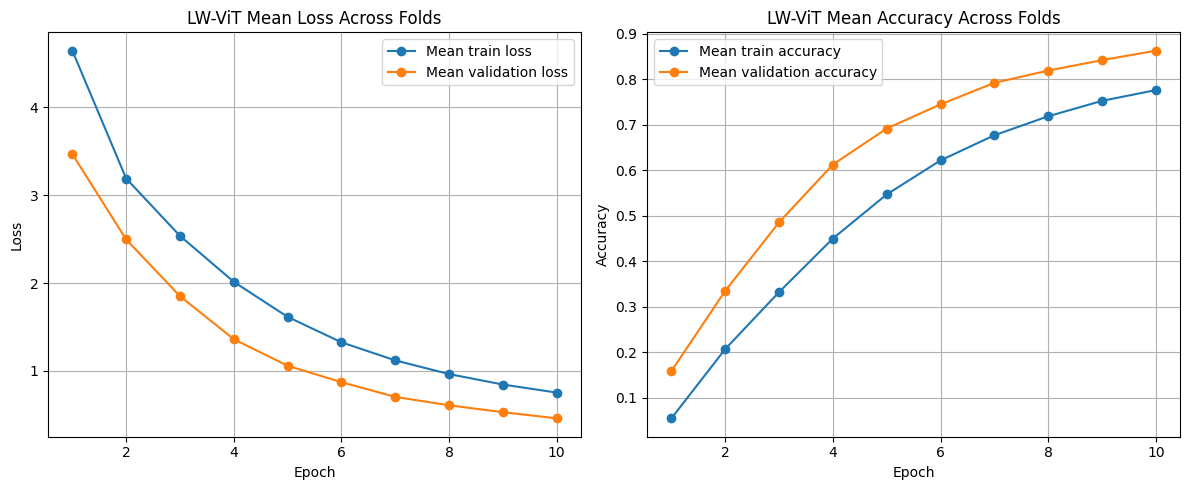

Training curves saved to: /content/drive/MyDrive/Diploma/diploma_hccr/results/figures/lwvit_training_curves.png


In [13]:
mean_history = history_df.groupby("epoch").agg({
    "train_loss": "mean",
    "validation_loss": "mean",
    "train_accuracy": "mean",
    "validation_accuracy": "mean",
    "train_f1": "mean",
    "validation_f1": "mean"
}).reset_index()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mean_history["epoch"], mean_history["train_loss"], marker="o", label="Mean train loss")
plt.plot(mean_history["epoch"], mean_history["validation_loss"], marker="o", label="Mean validation loss")
plt.title("LW-ViT Mean Loss Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mean_history["epoch"], mean_history["train_accuracy"], marker="o", label="Mean train accuracy")
plt.plot(mean_history["epoch"], mean_history["validation_accuracy"], marker="o", label="Mean validation accuracy")
plt.title("LW-ViT Mean Accuracy Across Folds")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

TRAINING_CURVES_PATH = FIGURES_DIR / "lwvit_training_curves.png"
plt.savefig(TRAINING_CURVES_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Training curves saved to:", TRAINING_CURVES_PATH)


## Load Best Cross-Validation Model


In [14]:
lwvit_model = create_lwvit_model(NUM_CLASSES).to(device)
lwvit_model.load_state_dict(best_overall_model_state)

print("Loaded best model from fold:", best_overall_fold)


Loaded best model from fold: 2


/tmp/ipykernel_18623/3833086799.py:52: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


## Evaluate LW-ViT on Test Set


In [15]:
criterion = nn.CrossEntropyLoss()

test_loss, test_accuracy, test_f1 = evaluate_model(
    model=lwvit_model,
    data_loader=test_loader,
    criterion=criterion,
    device=device
)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))
print("Test macro F1-score:", round(test_f1, 4))


Test loss: 0.4318
Test accuracy: 0.8736
Test macro F1-score: 0.8737


## Save Final Summary


In [ ]:
average_epoch_time = history_df["epoch_time"].mean()

summary = pd.DataFrame([{
    "model_name": "LW-ViT",
    "mean_validation_accuracy": cv_summary_df["best_validation_accuracy"].mean(),
    "mean_validation_f1": cv_summary_df["best_validation_f1"].mean(),
    "validation_accuracy_std": cv_summary_df["best_validation_accuracy"].std(),
    "validation_f1_std": cv_summary_df["best_validation_f1"].std(),
    "best_fold": best_overall_fold,
    "best_validation_accuracy": best_overall_accuracy,
    "best_validation_f1": best_overall_f1,
    "test_accuracy": test_accuracy,
    "test_f1": test_f1,
    "number_of_parameters": num_parameters,
    "model_size_mb": model_size_mb,
    "total_training_time": total_training_time,
    "average_epoch_time": average_epoch_time,
    "patch_size": PATCH_SIZE,
    "embed_dim": EMBED_DIM,
    "depth": DEPTH,
    "num_heads": NUM_HEADS,
    "mlp_dim": MLP_DIM
}])

SUMMARY_PATH = RESULTS_DIR / "lwvit_summary.csv"

summary.to_csv(SUMMARY_PATH, index=False)

print("Summary saved to:", SUMMARY_PATH)
summary


## Install Chinese Font for Prediction Visualization


In [ ]:
# Install a font that supports Chinese characters
!apt-get -qq install fonts-noto-cjk


In [ ]:
font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
chinese_font = fm.FontProperties(fname=font_path)

plt.rcParams["axes.unicode_minus"] = False


## Visualize Random Test Predictions


In [ ]:
test_labels, test_predictions = get_predictions(
    model=lwvit_model,
    data_loader=test_loader,
    device=device
)

random_indices = random.sample(range(len(test_dataset)), 16)

plt.figure(figsize=(12, 12))

for plot_index, sample_index in enumerate(random_indices):
    image, true_index = test_dataset[sample_index]

    # Convert values back to the visible range
    image = image.squeeze(0)
    image = image * 0.5 + 0.5

    predicted_index = test_predictions[sample_index].item()

    true_label = idx_to_class[true_index]
    predicted_label = idx_to_class[predicted_index]

    title_color = "green" if true_index == predicted_index else "red"

    plt.subplot(4, 4, plot_index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"True: {true_label}\nPred: {predicted_label}",
        fontproperties=chinese_font,
        fontsize=12,
        color=title_color
    )
    plt.axis("off")

plt.tight_layout()

PREDICTIONS_FIGURE_PATH = FIGURES_DIR / "lwvit_random_test_predictions.png"
plt.savefig(PREDICTIONS_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Prediction figure saved to:", PREDICTIONS_FIGURE_PATH)


## Confusion Matrix for Most Confused Classes


In [2]:
from pathlib import Path
import sys
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm import tqdm


PROJECT_DIR = Path.cwd()

# If the notebook is opened from another folder, set the project root manually
if PROJECT_DIR.name == "diploma_hccr":
    PROJECT_DIR = PROJECT_DIR.parent

sys.path.append(str(PROJECT_DIR / "diploma_hccr"))

from model_architecture import create_lwvit_model


TEST_DIR = PROJECT_DIR / "CASIA_246" / "test"
MODEL_PATH = PROJECT_DIR / "diploma_hccr" / "models" / "lwvit.pth"
RESULTS_DIR = PROJECT_DIR / "diploma_hccr" / "results"
FIGURES_DIR = RESULTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project folder:", PROJECT_DIR)
print("Test folder:", TEST_DIR)
print("Model path:", MODEL_PATH)

assert TEST_DIR.exists(), f"Test folder not found: {TEST_DIR}"
assert MODEL_PATH.exists(), f"Model checkpoint not found: {MODEL_PATH}"


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Device:", device)


checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=False
)

NUM_CLASSES = int(checkpoint.get("num_classes", 246))
IMAGE_SIZE = int(checkpoint.get("image_size", 64))
BATCH_SIZE = 64

lwvit_model = create_lwvit_model(num_classes=NUM_CLASSES)
lwvit_model.load_state_dict(checkpoint["model_state_dict"])
lwvit_model.to(device)
lwvit_model.eval()

print("LW-ViT model loaded.")


Project folder: /Users/dina/Downloads/Diploma
Test folder: /Users/dina/Downloads/Diploma/CASIA_246/test
Model path: /Users/dina/Downloads/Diploma/diploma_hccr/models/lwvit.pth
Device: mps
LW-ViT model loaded.


/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [3]:
def fix_chinese_label(label):
    """
    Fix labels that were stored as UTF-8 text but decoded as cp437.
    Correct labels are returned unchanged.
    """
    if not isinstance(label, str):
        return str(label)

    try:
        fixed_label = label.encode("cp437").decode("utf-8")
        has_chinese = any("\u4e00" <= char <= "\u9fff" for char in fixed_label)

        if has_chinese:
            return fixed_label

    except (UnicodeEncodeError, UnicodeDecodeError):
        pass

    return label


test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

checkpoint_class_to_idx = {
    fix_chinese_label(class_name): int(class_index)
    for class_name, class_index in checkpoint["class_to_idx"].items()
}

idx_to_class = {
    class_index: class_name
    for class_name, class_index in checkpoint_class_to_idx.items()
}

# Local ImageFolder labels are remapped to the checkpoint labels
dataset_label_to_checkpoint_label = {}

for class_name, dataset_index in test_dataset.class_to_idx.items():
    fixed_class_name = fix_chinese_label(class_name)
    dataset_label_to_checkpoint_label[dataset_index] = checkpoint_class_to_idx[fixed_class_name]

label_remap = torch.tensor(
    [dataset_label_to_checkpoint_label[index] for index in range(len(test_dataset.classes))],
    dtype=torch.long
)

print("Test images:", len(test_dataset))
print("Number of classes:", NUM_CLASSES)

print("First 10 labels:")
for index in range(10):
    print(index, idx_to_class[index])


Test images: 35108
Number of classes: 246
First 10 labels:
0 歌
1 正
2 本
3 月
4 有
5 服
6 朋
7 期
8 机
9 杯


In [4]:
test_true_labels = []
test_predictions = []
test_probabilities = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Collecting LW-ViT predictions"):
        images = images.to(device)

        mapped_labels = label_remap[labels].to(device)

        outputs = lwvit_model(images)
        probabilities = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(probabilities, dim=1)

        test_true_labels.extend(mapped_labels.cpu().numpy())
        test_predictions.extend(predictions.cpu().numpy())
        test_probabilities.extend(probabilities.cpu().numpy())

test_true_labels = np.array(test_true_labels)
test_predictions = np.array(test_predictions)
test_probabilities = np.array(test_probabilities)

test_accuracy = accuracy_score(test_true_labels, test_predictions)
test_f1 = f1_score(test_true_labels, test_predictions, average="macro")

print("Test accuracy:", round(test_accuracy, 4))
print("Test macro F1-score:", round(test_f1, 4))


prediction_rows = []

for sample_index, (image_path, _) in enumerate(test_dataset.samples):
    true_index = int(test_true_labels[sample_index])
    predicted_index = int(test_predictions[sample_index])
    confidence = float(test_probabilities[sample_index, predicted_index])

    prediction_rows.append({
        "image_path": image_path,
        "true_label": idx_to_class[true_index],
        "predicted_label": idx_to_class[predicted_index],
        "true_class_index": true_index,
        "predicted_class_index": predicted_index,
        "confidence": confidence,
        "is_correct": true_index == predicted_index
    })

predictions_df = pd.DataFrame(prediction_rows)

PREDICTIONS_CSV_PATH = RESULTS_DIR / "lwvit_test_predictions.csv"
predictions_df.to_csv(PREDICTIONS_CSV_PATH, index=False, encoding="utf-8-sig")

print("Predictions saved to:", PREDICTIONS_CSV_PATH)


Test accuracy: 0.8737
Test macro F1-score: 0.8737
Predictions saved to: /Users/dina/Downloads/Diploma/diploma_hccr/results/lwvit_test_predictions.csv


In [5]:
font_candidates = [
    "/System/Library/Fonts/PingFang.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
    "/System/Library/Fonts/Supplemental/Songti.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
]

chinese_font = None

for font_path in font_candidates:
    if Path(font_path).exists():
        chinese_font = fm.FontProperties(fname=font_path)
        print("Using font:", font_path)
        break

plt.rcParams["axes.unicode_minus"] = False


Using font: /System/Library/Fonts/STHeiti Light.ttc


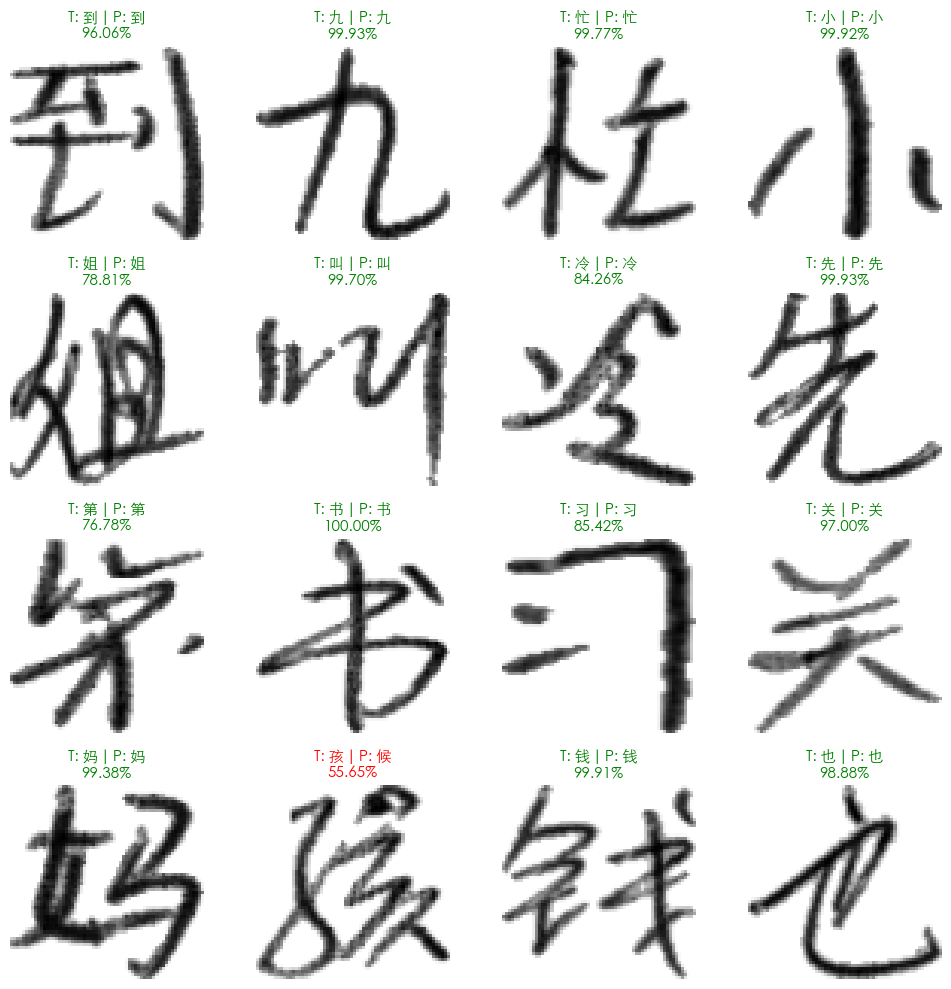

Random predictions saved to: /Users/dina/Downloads/Diploma/diploma_hccr/results/figures/lwvit_random_test_predictions.png


In [6]:
random.seed(42)

sample_indices = random.sample(range(len(test_dataset)), 16)

plt.figure(figsize=(10, 10))

for plot_index, sample_index in enumerate(sample_indices):
    image_tensor, _ = test_dataset[sample_index]

    true_index = int(test_true_labels[sample_index])
    predicted_index = int(test_predictions[sample_index])

    true_character = idx_to_class[true_index]
    predicted_character = idx_to_class[predicted_index]
    confidence = test_probabilities[sample_index, predicted_index]

    image = image_tensor.squeeze(0)
    image = image * 0.5 + 0.5

    title_color = "green" if true_index == predicted_index else "red"

    plt.subplot(4, 4, plot_index + 1)
    plt.imshow(image, cmap="gray")
    plt.title(
        f"T: {true_character} | P: {predicted_character}\n{confidence:.2%}",
        fontproperties=chinese_font,
        fontsize=11,
        color=title_color
    )
    plt.axis("off")

plt.tight_layout()

PREDICTIONS_FIGURE_PATH = FIGURES_DIR / "lwvit_random_test_predictions.png"
plt.savefig(PREDICTIONS_FIGURE_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Random predictions saved to:", PREDICTIONS_FIGURE_PATH)


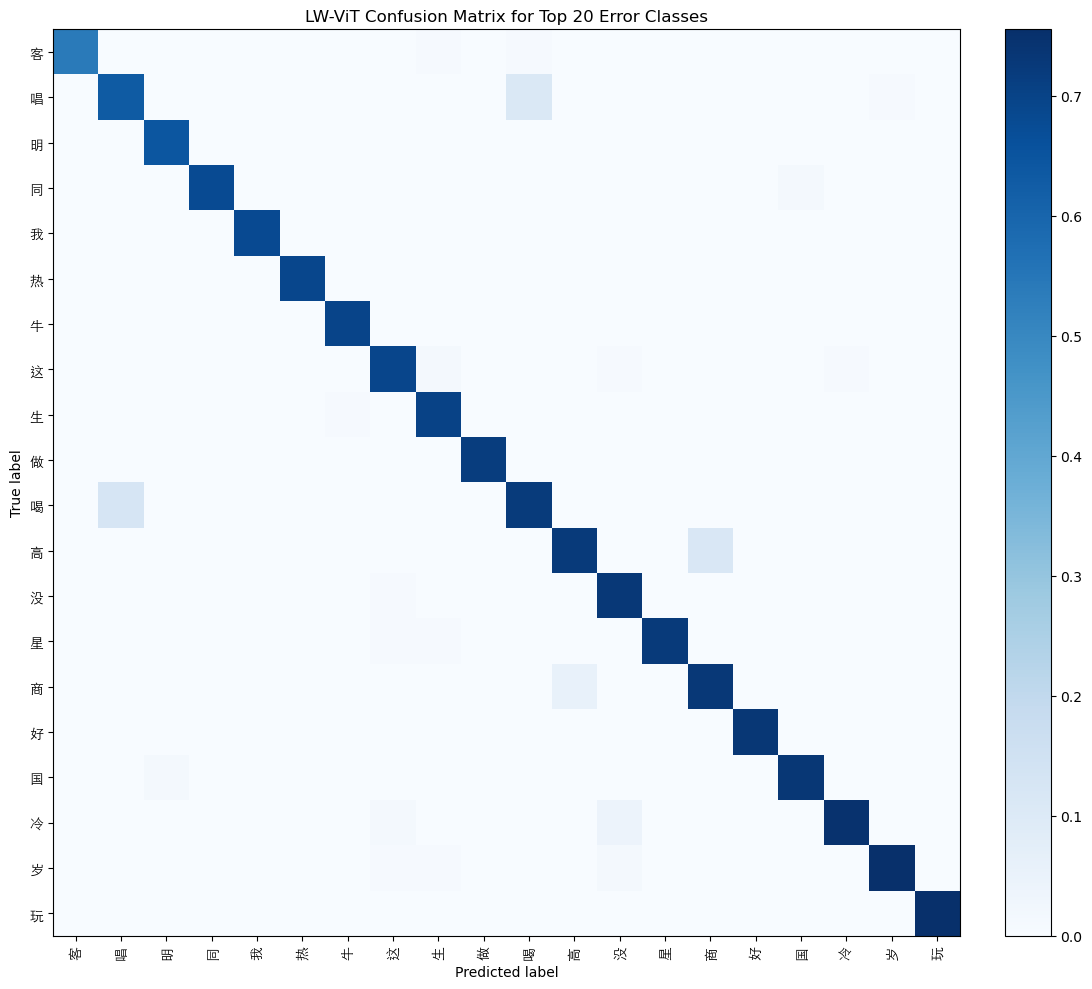

Confusion matrix saved to: /Users/dina/Downloads/Diploma/diploma_hccr/results/figures/lwvit_confusion_matrix_top20.png


In [7]:
cm = confusion_matrix(
    test_true_labels,
    test_predictions,
    labels=np.arange(NUM_CLASSES)
)

class_error_counts = cm.sum(axis=1) - np.diag(cm)

top_k = 20
top_error_classes = np.argsort(class_error_counts)[::-1][:top_k]

cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_normalized = np.nan_to_num(cm_normalized)

top_cm = cm_normalized[np.ix_(top_error_classes, top_error_classes)]
top_class_labels = [
    idx_to_class[int(class_index)]
    for class_index in top_error_classes
]

plt.figure(figsize=(12, 10))
plt.imshow(top_cm, cmap="Blues")
plt.colorbar(fraction=0.046, pad=0.04)

plt.title("LW-ViT Confusion Matrix for Top 20 Error Classes")
plt.xlabel("Predicted label")
plt.ylabel("True label")

plt.xticks(
    ticks=np.arange(top_k),
    labels=top_class_labels,
    rotation=90,
    fontproperties=chinese_font
)

plt.yticks(
    ticks=np.arange(top_k),
    labels=top_class_labels,
    fontproperties=chinese_font
)

plt.tight_layout()

CONFUSION_MATRIX_PATH = FIGURES_DIR / "lwvit_confusion_matrix_top20.png"
plt.savefig(CONFUSION_MATRIX_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix saved to:", CONFUSION_MATRIX_PATH)


The LW-ViT experiment is complete. The trained model, training history, training curves, test summary, confusion matrix, and prediction visualization were saved to Google Drive.
